In [14]:
library(mclust)
library(cluster)
library(ggplot2)
library(factoextra)
library(fastDummies)
library(clustMD)

In [15]:
options(repr.plot.width = 25, repr.plot.height = 25) 

**Ejercicio 1:**

a) Explique como funciona el método Mclust, describa los principales parámetros de entrada y salida.

b) Utilice Mclust sin definir el número de grupos y considere el Criterio de información Bayesiano (BIC) para decidir el número de grupos óptimo. 

c) Interprete y comente los resultados obtenidos. Compare  sus resultados con aquellos obtenidos con k-means.

**Ejercicio 2:** 

a) Estudie las medidas de calidad propuestas en Murphy, Capítulo 25: purity, rand index y mutual information (pdf en siveducMD) y resuma brevemente en que consisten.

Considere el archivo "semillas.txt" que contiene una séptima variable con la clasificación de las semillas en tres variedades: 
- 1: Kama
- 2: Rosa
- 3: Canadian

b) Calcule alguna de las medidas de calidad estudiadas para los agrupamientos obtenidos con KMeans (tarea anterior) y GMM, considerando la etiqueta en V7 para sus cálculos. Compare y discuta sus resultados.

**Ejercicio 3:** 

a) Realice el análisis de agrupamiento de los datos asignados a su grupo utilizando GMM.

b) Interprete sus resultados y compare con los obtenidos con k-means.

   distancia          tiempo          velocidad         modo_transporte_bus
 Min.   : 0.020   Min.   :0.05733   Min.   :  0.01573   Min.   :0.0000     
 1st Qu.: 8.675   1st Qu.:0.53700   1st Qu.: 12.12287   1st Qu.:0.0000     
 Median :15.615   Median :0.78542   Median : 18.95680   Median :0.0000     
 Mean   :16.820   Mean   :0.84357   Mean   : 26.45919   Mean   :0.3302     
 3rd Qu.:22.878   3rd Qu.:1.04221   3rd Qu.: 31.72714   3rd Qu.:1.0000     
 Max.   :77.310   Max.   :4.23100   Max.   :157.50000   Max.   :1.0000     
 modo_transporte_bicicleta modo_transporte_auto modo_transporte_caminar
 Min.   :0.0000            Min.   :0.0000       Min.   :0.0000         
 1st Qu.:0.0000            1st Qu.:0.0000       1st Qu.:0.0000         
 Median :0.0000            Median :0.0000       Median :0.0000         
 Mean   :0.3767            Mean   :0.1047       Mean   :0.1512         
 3rd Qu.:1.0000            3rd Qu.:0.0000       3rd Qu.:0.0000         
 Max.   :1.0000            Max.   :1

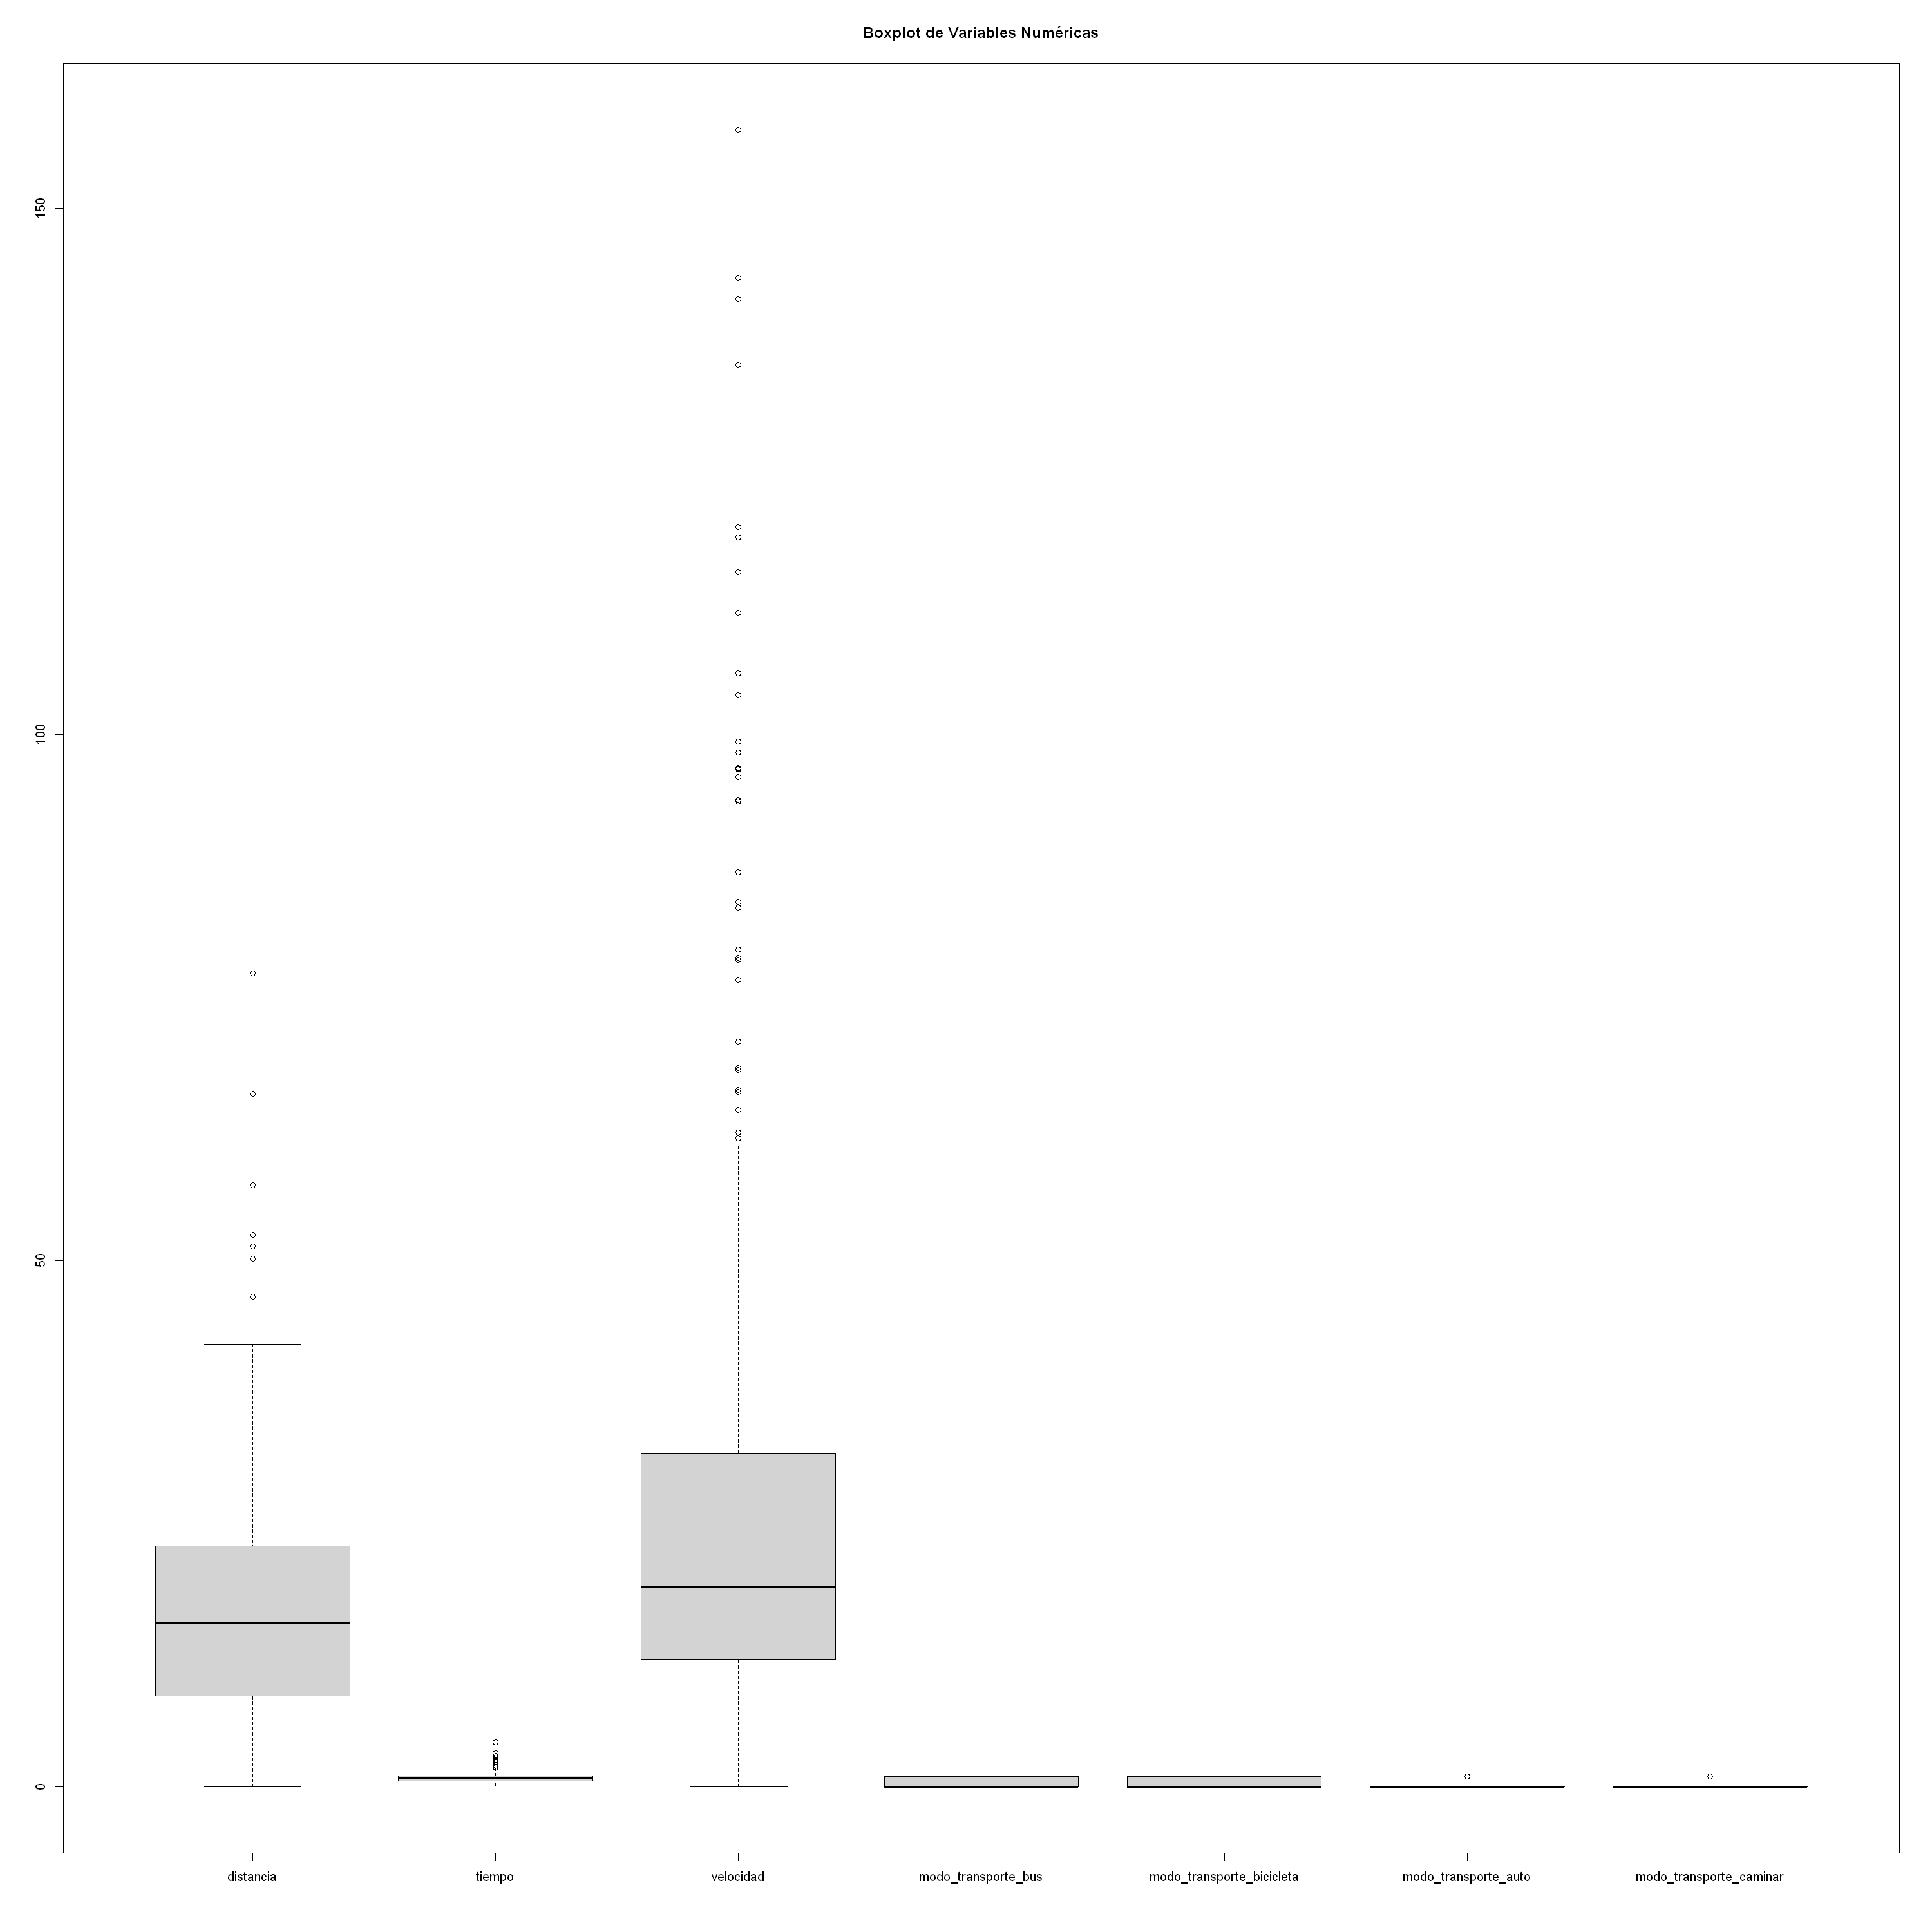

In [16]:
# Se cargan los datos originales
datos_grupo <- read.csv("..//datasets_simulados//Grupo10.csv", dec=".", sep=",")

datos_grupo <- dummy_cols(datos_grupo, select_columns = "modo_transporte", remove_selected_columns = FALSE)

# Se filtran valores negativos y nulos (Ya que no tienen sentido logico)
datos_grupo <- datos_grupo[datos_grupo$distancia > 0 & datos_grupo$tiempo > 0 & datos_grupo$viajes > 0, ]
datos_grupo <- na.omit(datos_grupo)

# Agregamos velocidad (en kilometros) promedio antes de filtrar. Tambien quitamos velocidades que no tienen sentido 
# (Velocidades sobre 160 kilometros por hora, teniendo en cuenta que la velocidad maxima en chile es 120km/h en autopista y que algunos trenes efe podrian llegar a 160km/h en algunos tramos).
datos_grupo$tiempo <- datos_grupo$tiempo / 60
datos_grupo$velocidad <- datos_grupo$distancia / datos_grupo$tiempo
datos_grupo <- datos_grupo[datos_grupo$velocidad <= 160, ]

# Solo usamos los datos numericos.
datos_num <- datos_grupo[ , c("distancia", "tiempo", "velocidad", "modo_transporte_bus", "modo_transporte_bicicleta", "modo_transporte_auto", "modo_transporte_caminar")]

summary(datos_num)
boxplot(datos_num, main="Boxplot de Variables Numéricas")

In [ ]:
datos_scale = scale(datos_num)
clus <- Mclust(datos_scale)
summary(clus)

---------------------------------------------------- 
Gaussian finite mixture model fitted by EM algorithm 
---------------------------------------------------- 

Mclust VEV (ellipsoidal, equal shape) model with 2 components: 

 log-likelihood   n df       BIC       ICL
      -2678.112 430 65 -5750.369 -5750.369

Clustering table:
  1   2 
274 156 

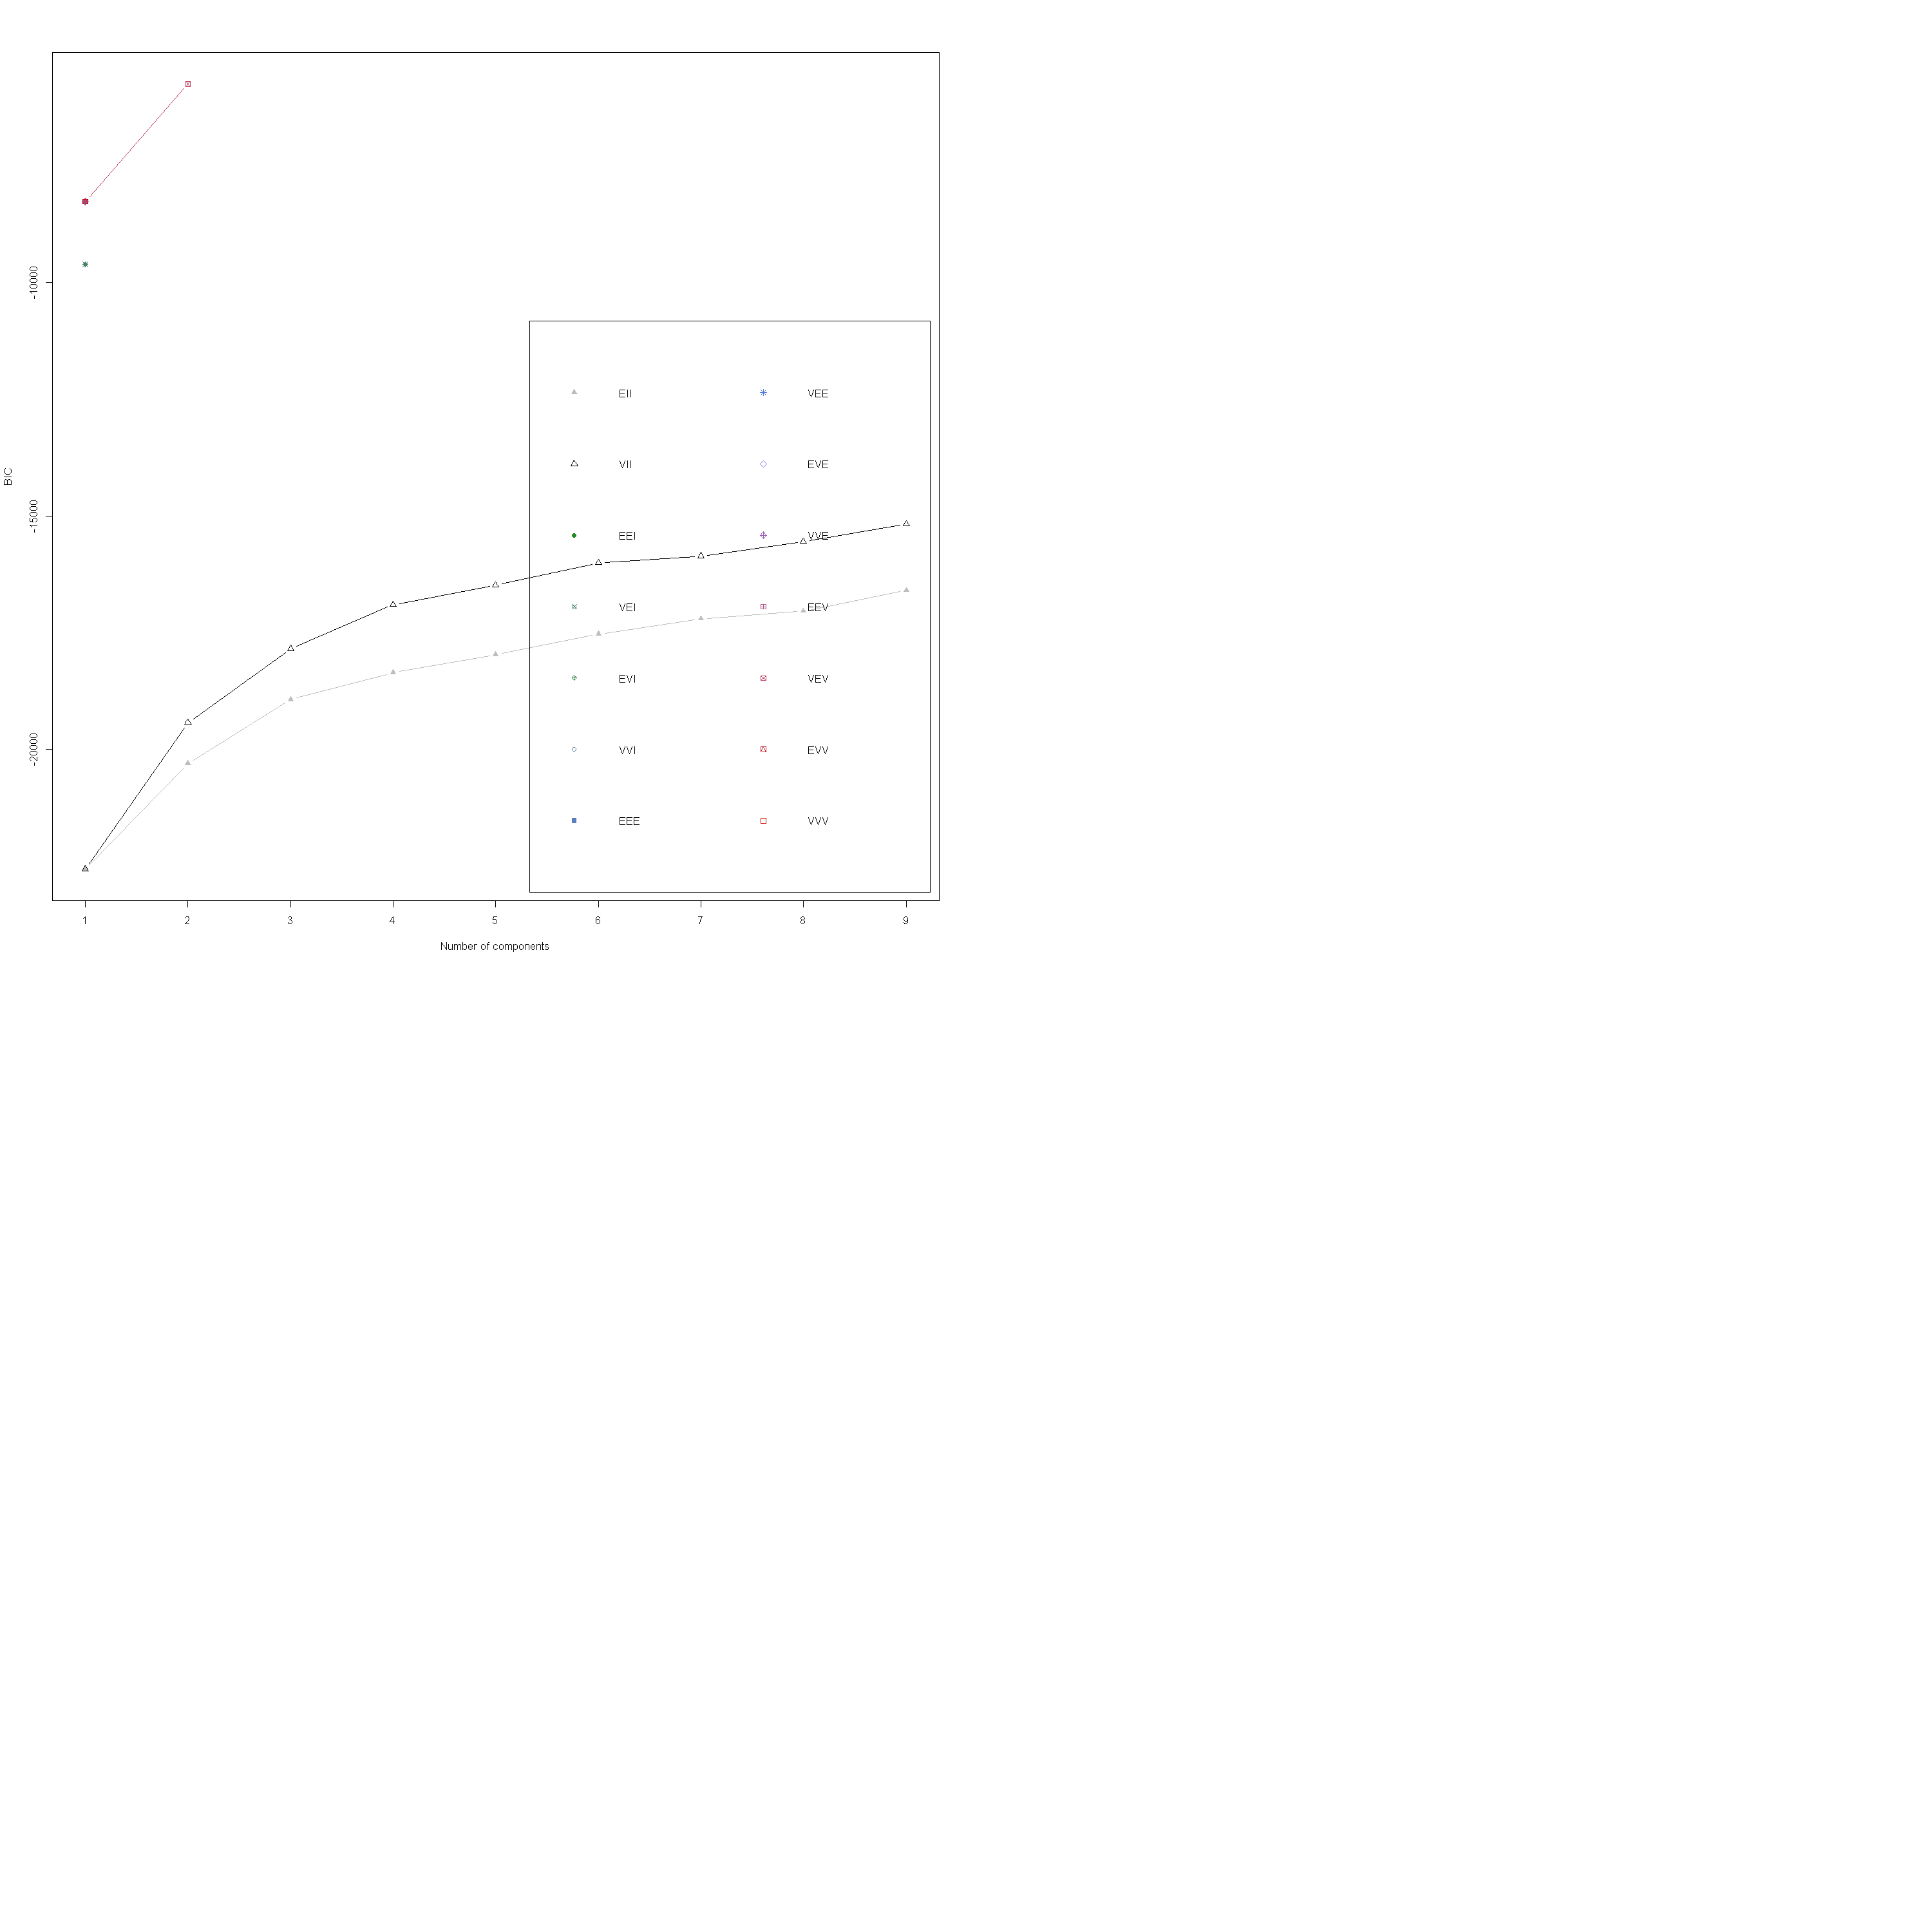

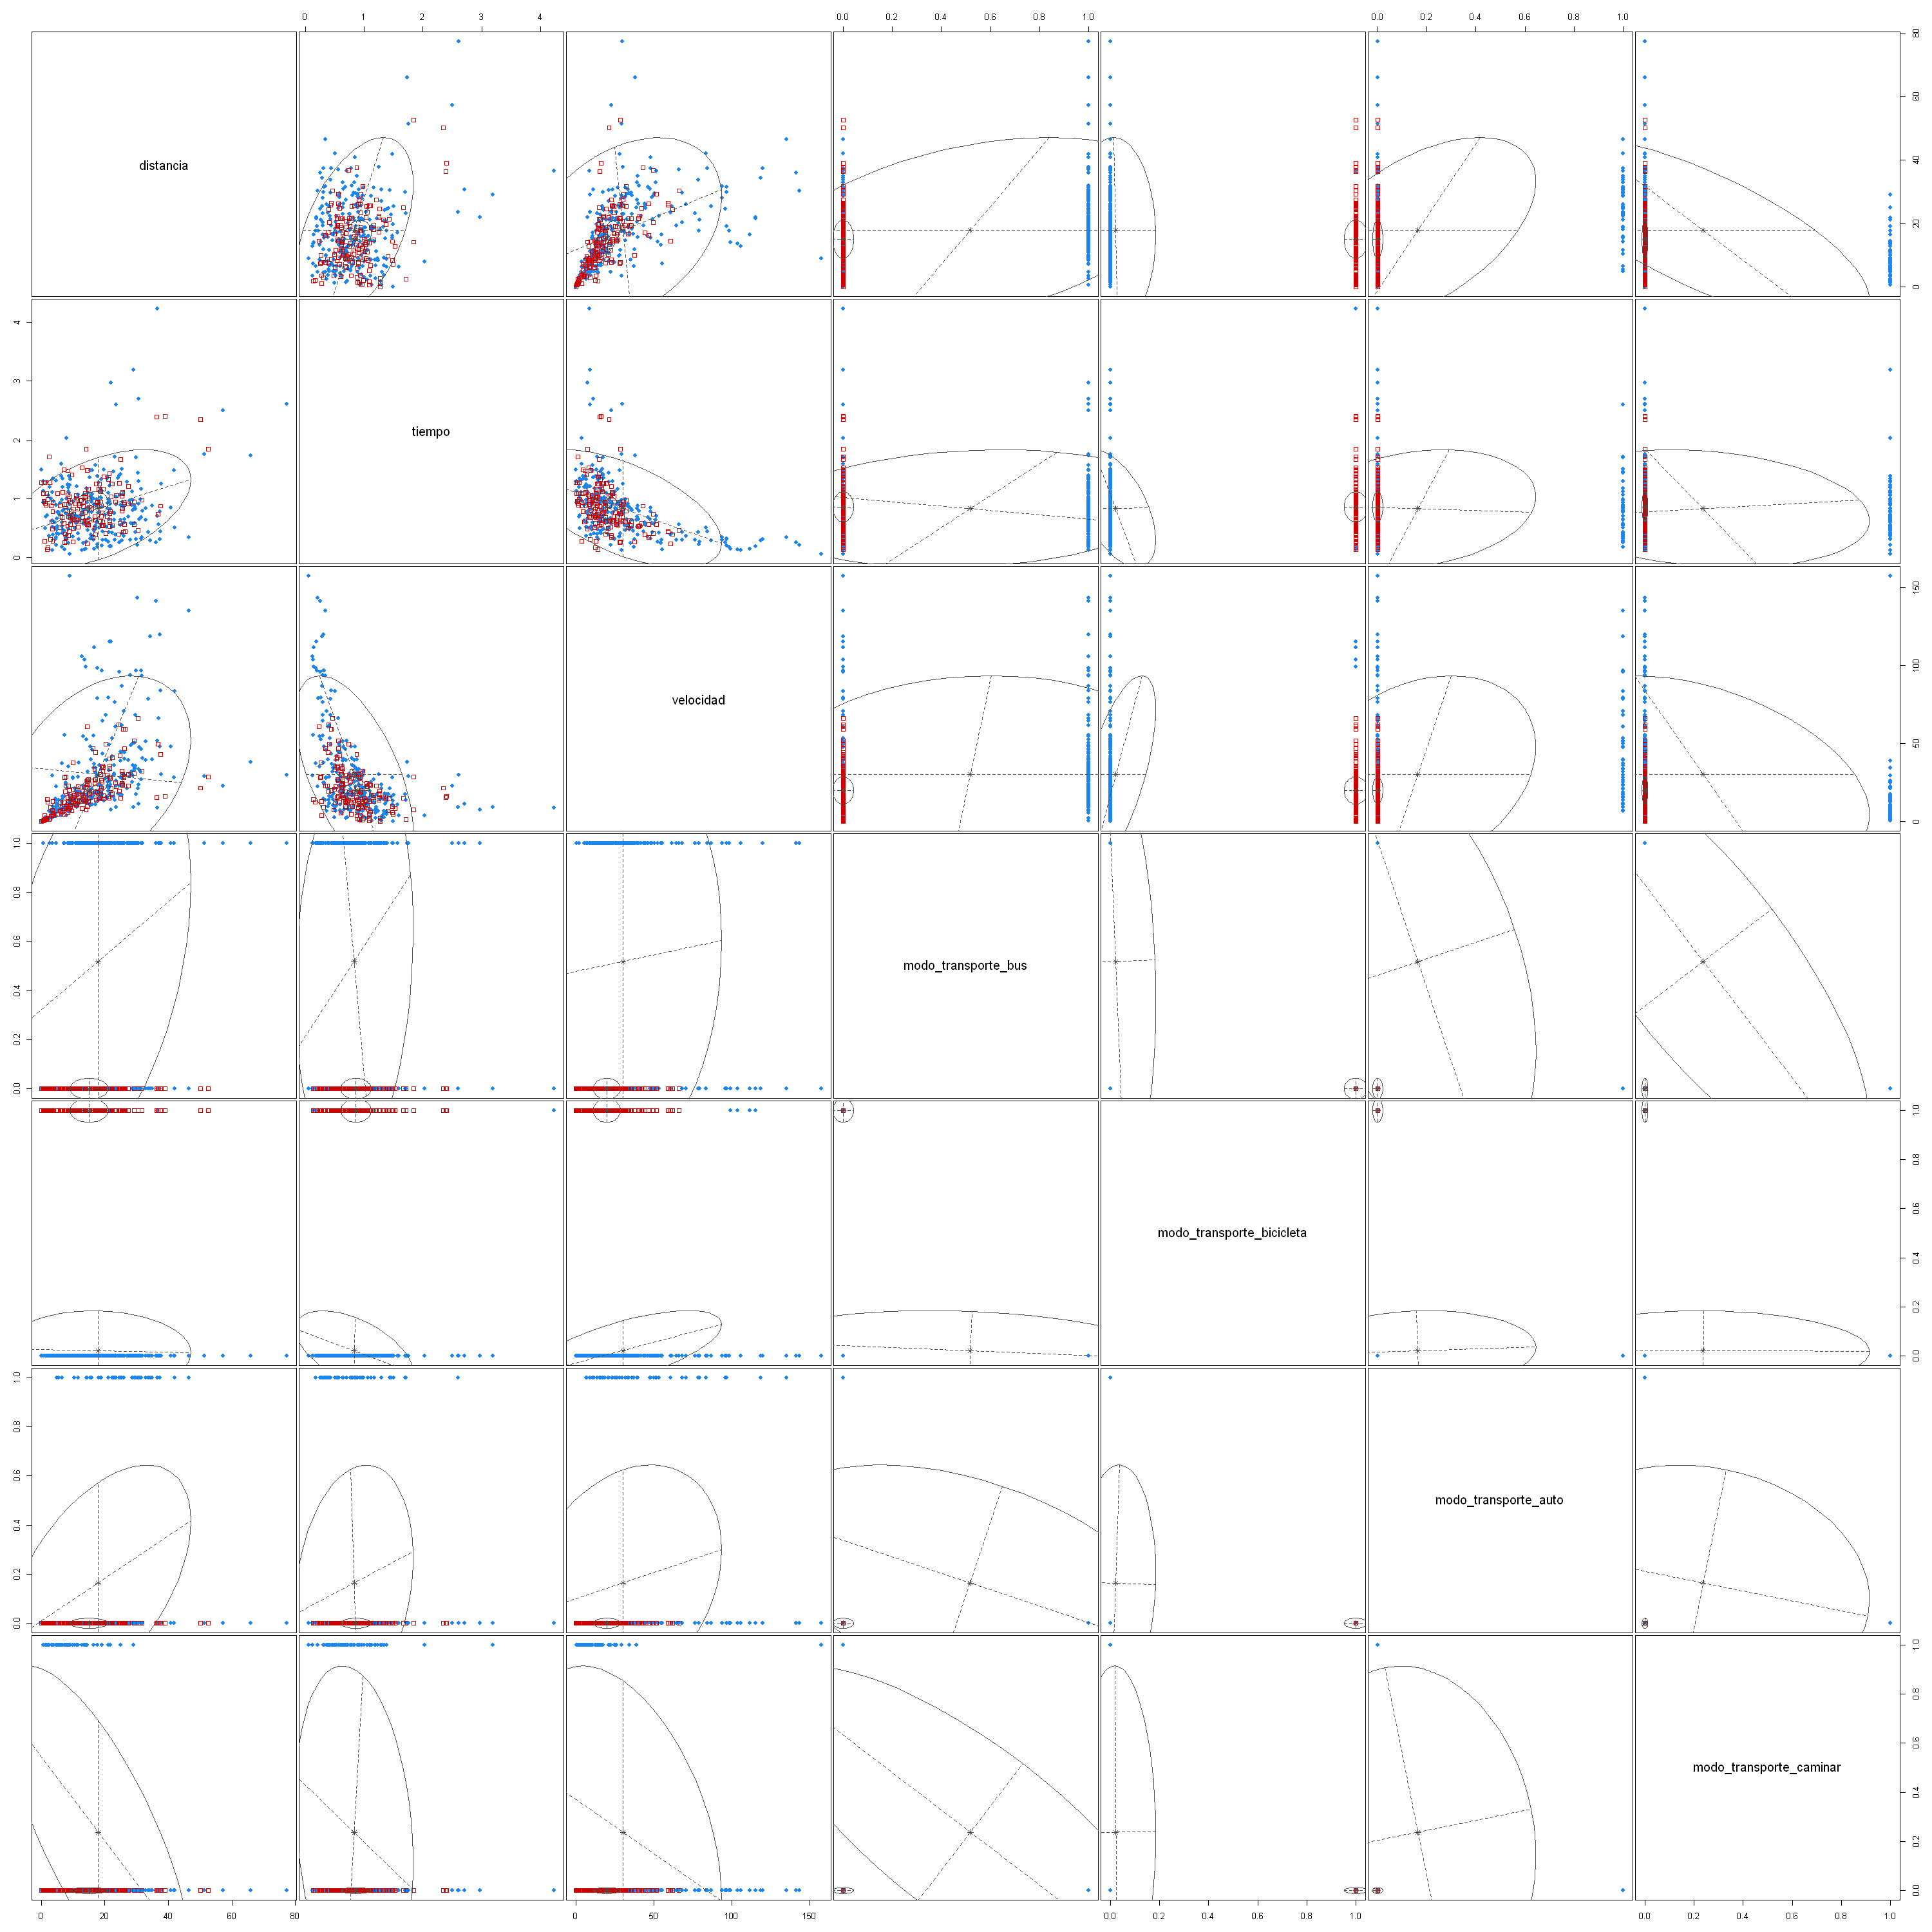

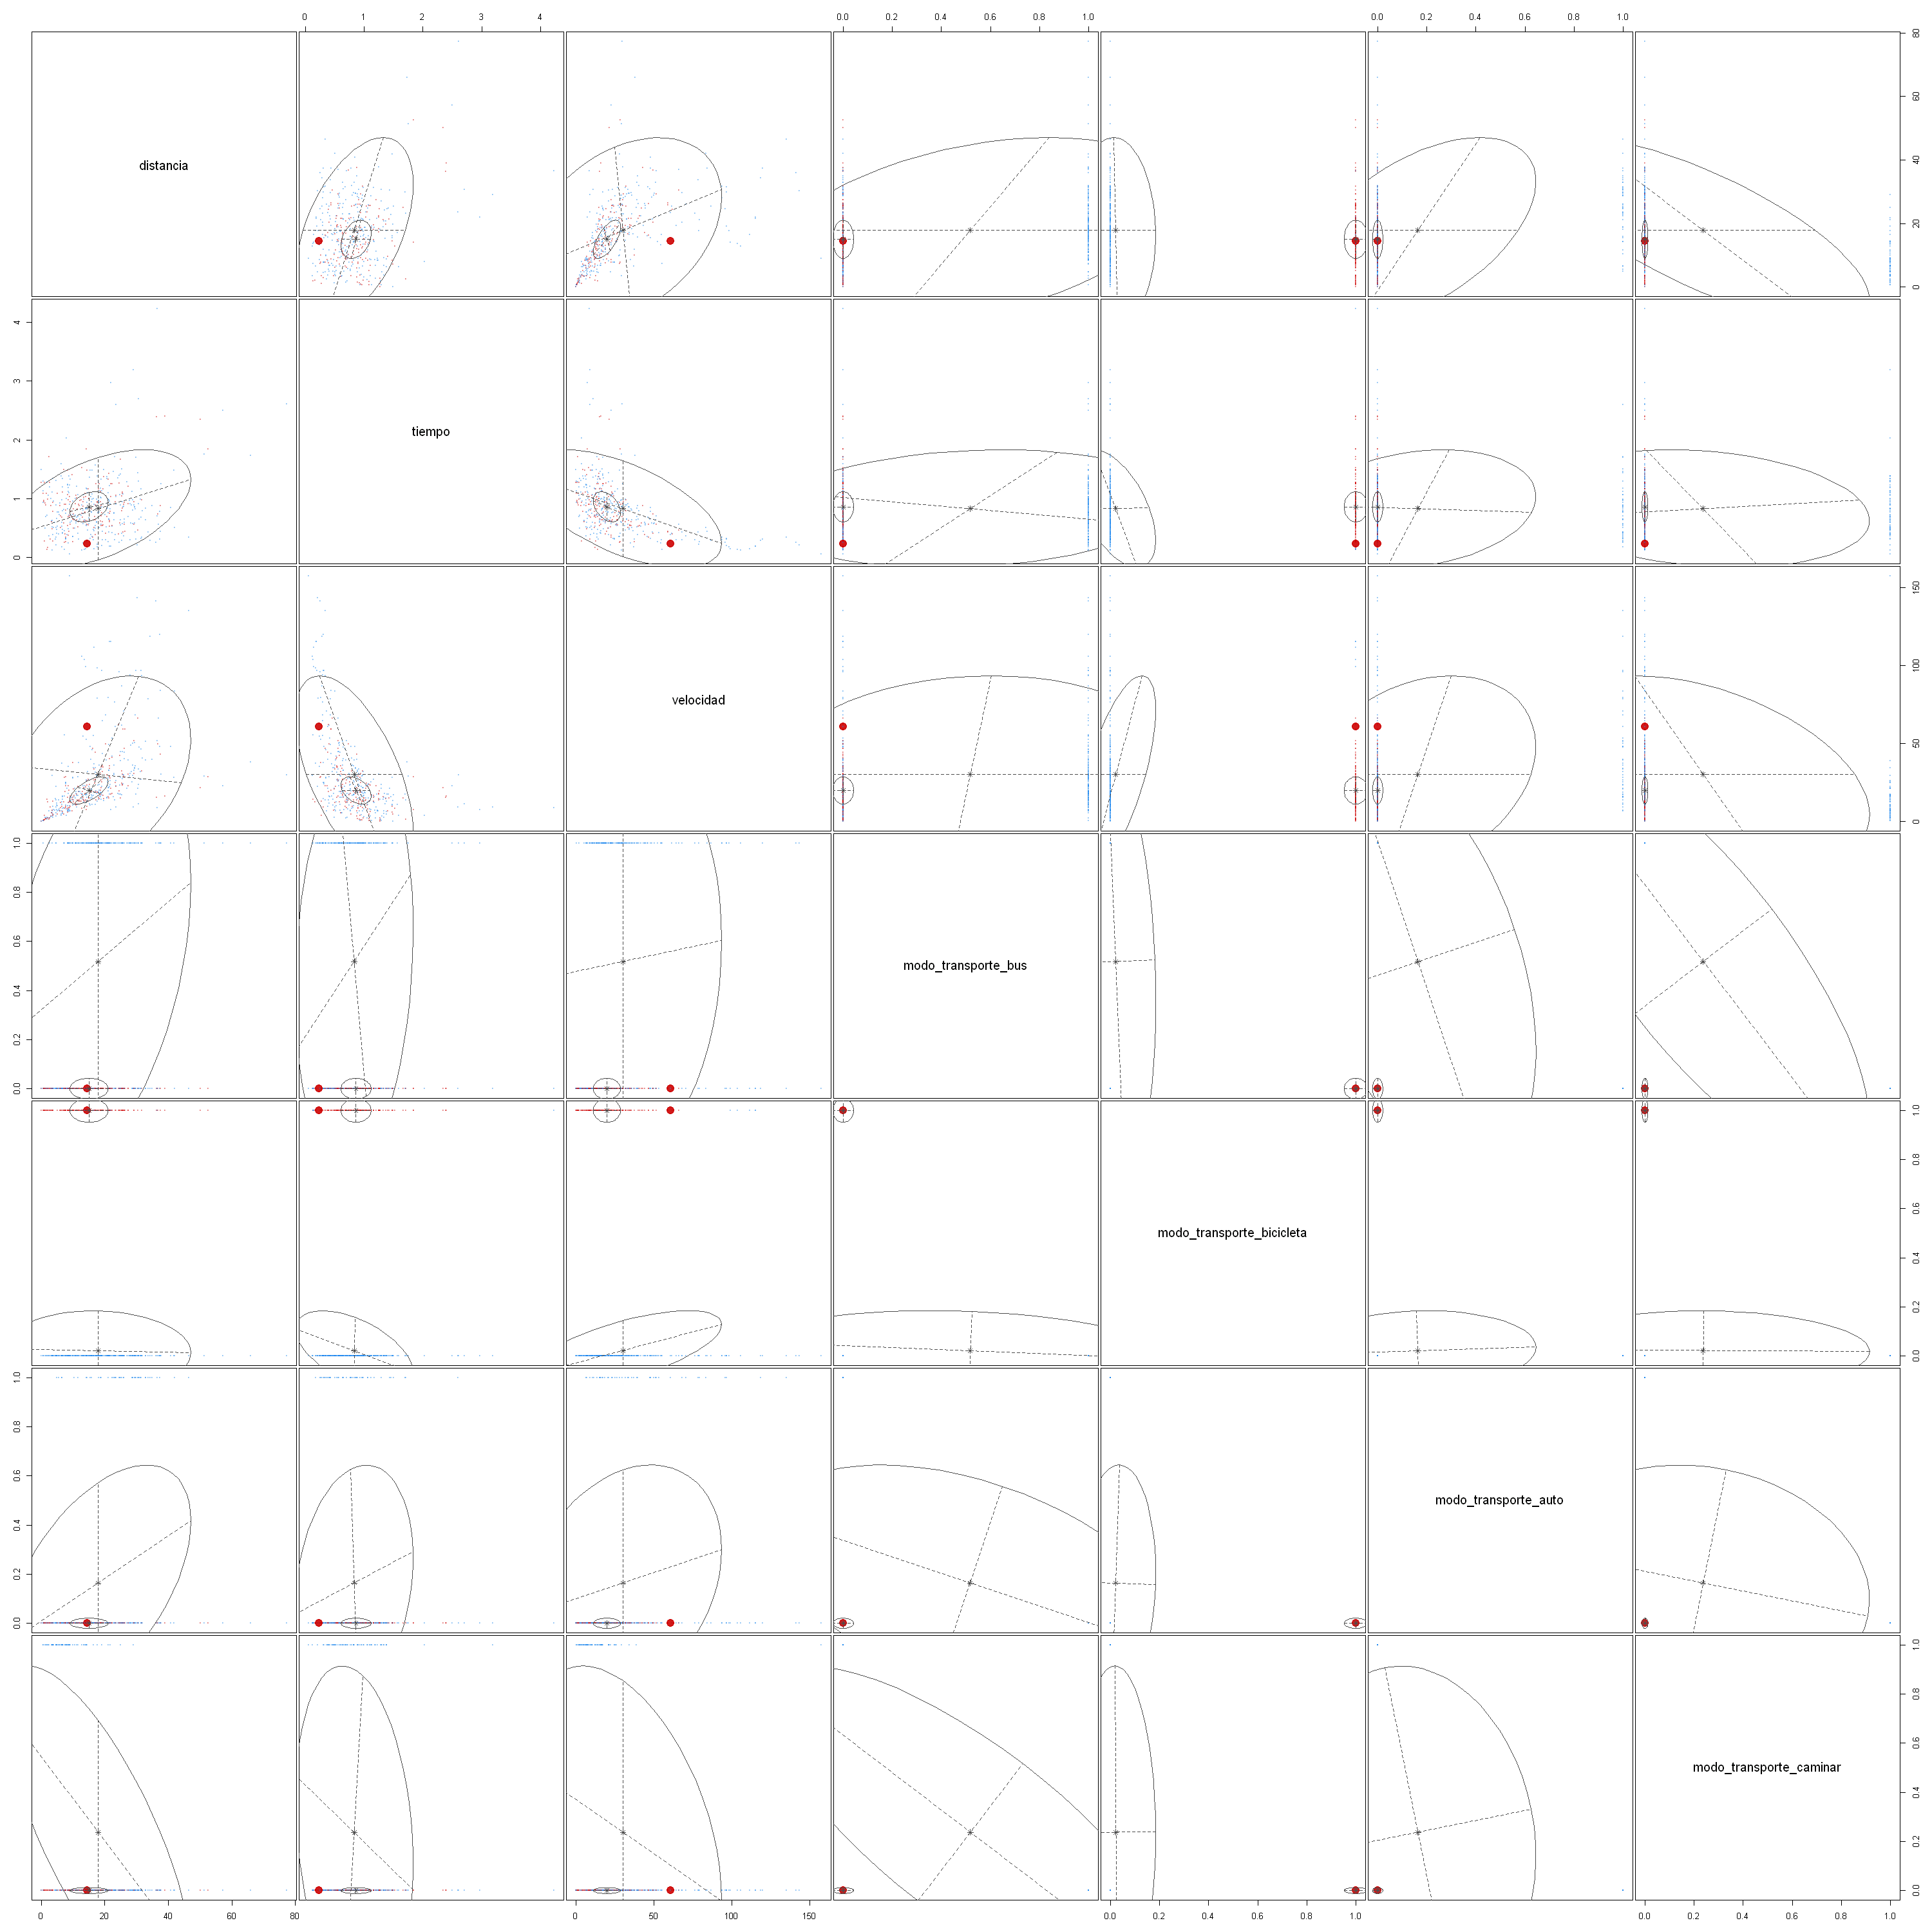

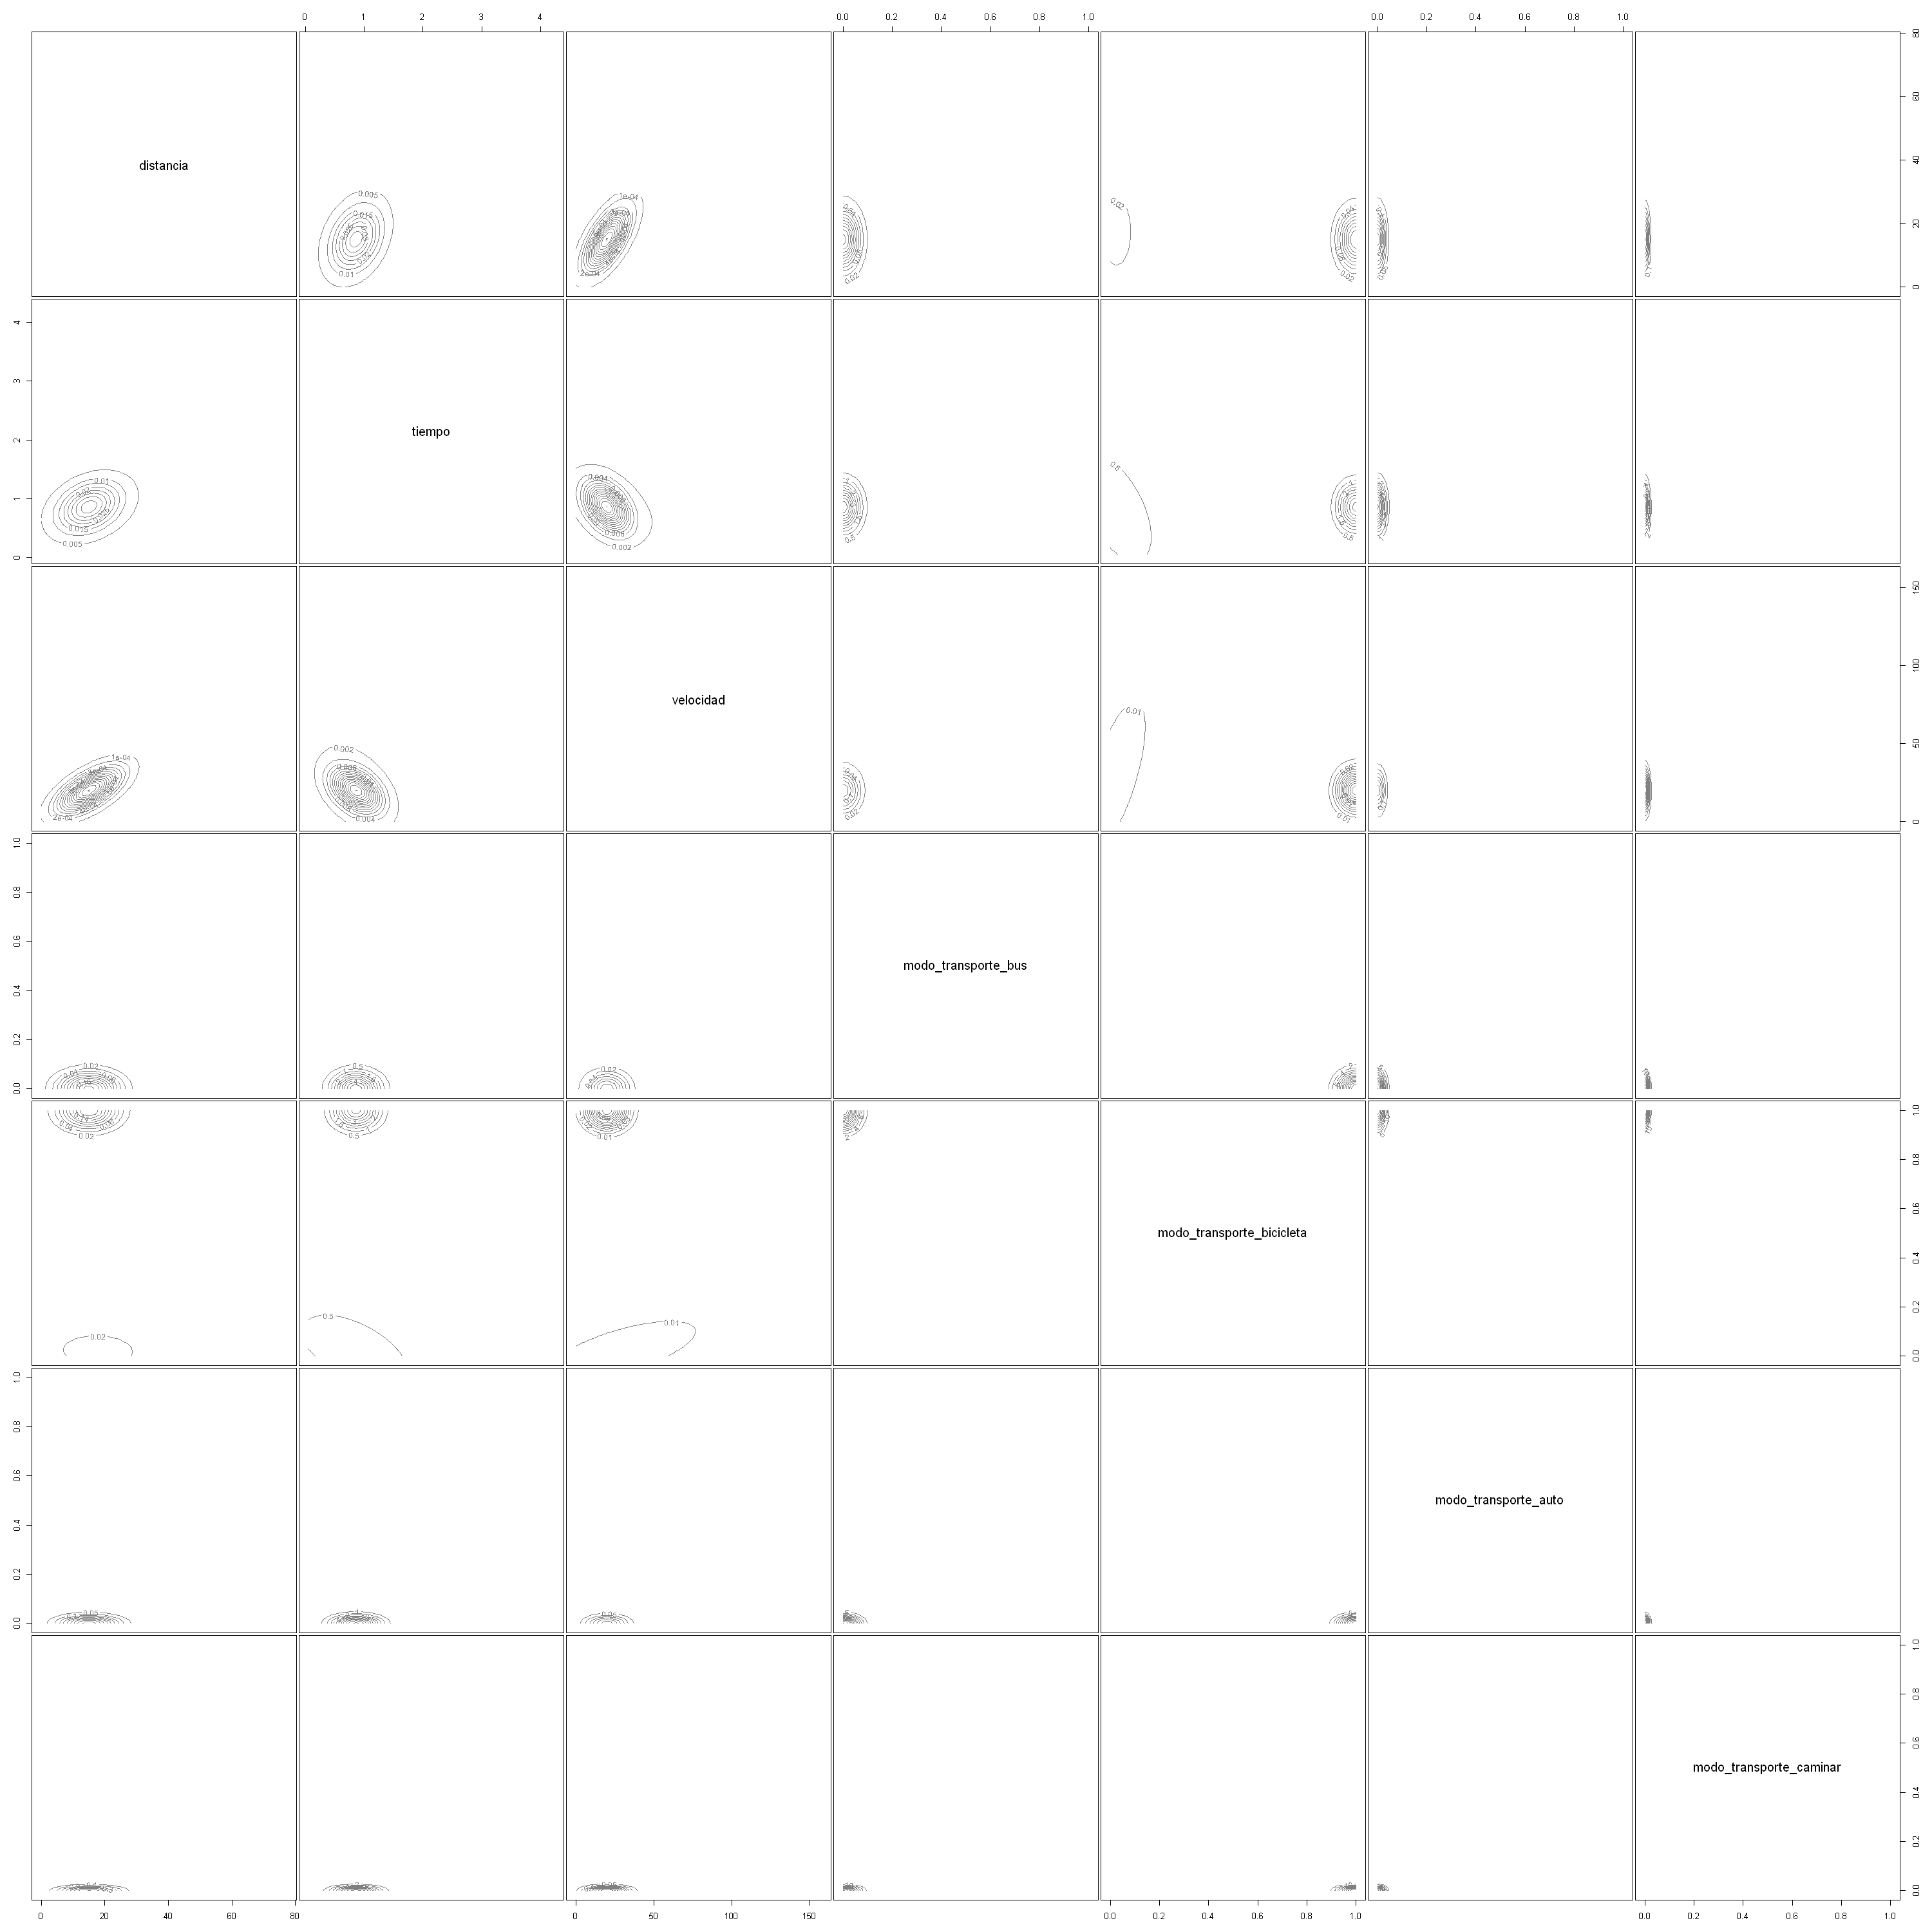

In [18]:
par(mfrow = c(2, 2))
plot(clus, what = "BIC")            # curva BIC → G óptimo
plot(clus, what = "classification") # mapa de clusters
plot(clus, what = "uncertainty")    # incertidumbre de asignación
plot(clus, what = "density")        # densidad estimada

In [19]:
cl <- clus$classification
for (g in 1:clus$G) {
  cat("\n--- Cluster", g, "(n =", sum(cl == g), ") ---\n")
  print(apply(datos_scale[cl == g, ], 2, summary))
}


--- Cluster 1 (n = 274 ) ---
        distancia     tiempo   velocidad modo_transporte_bus
Min.      0.06000 0.05733333   0.0400757           0.0000000
1st Qu.   8.82000 0.49408333  12.4332089           0.0000000
Median   16.62500 0.76558333  21.1229890           1.0000000
Mean     17.84161 0.83234124  30.1744592           0.5182482
3rd Qu.  24.75250 1.04591667  36.0194852           1.0000000
Max.     77.31000 4.23100000 157.5000000           1.0000000
        modo_transporte_bicicleta modo_transporte_auto modo_transporte_caminar
Min.                   0.00000000            0.0000000               0.0000000
1st Qu.                0.00000000            0.0000000               0.0000000
Median                 0.00000000            0.0000000               0.0000000
Mean                   0.02189781            0.1642336               0.2372263
3rd Qu.                0.00000000            0.0000000               0.0000000
Max.                   1.00000000            1.0000000               

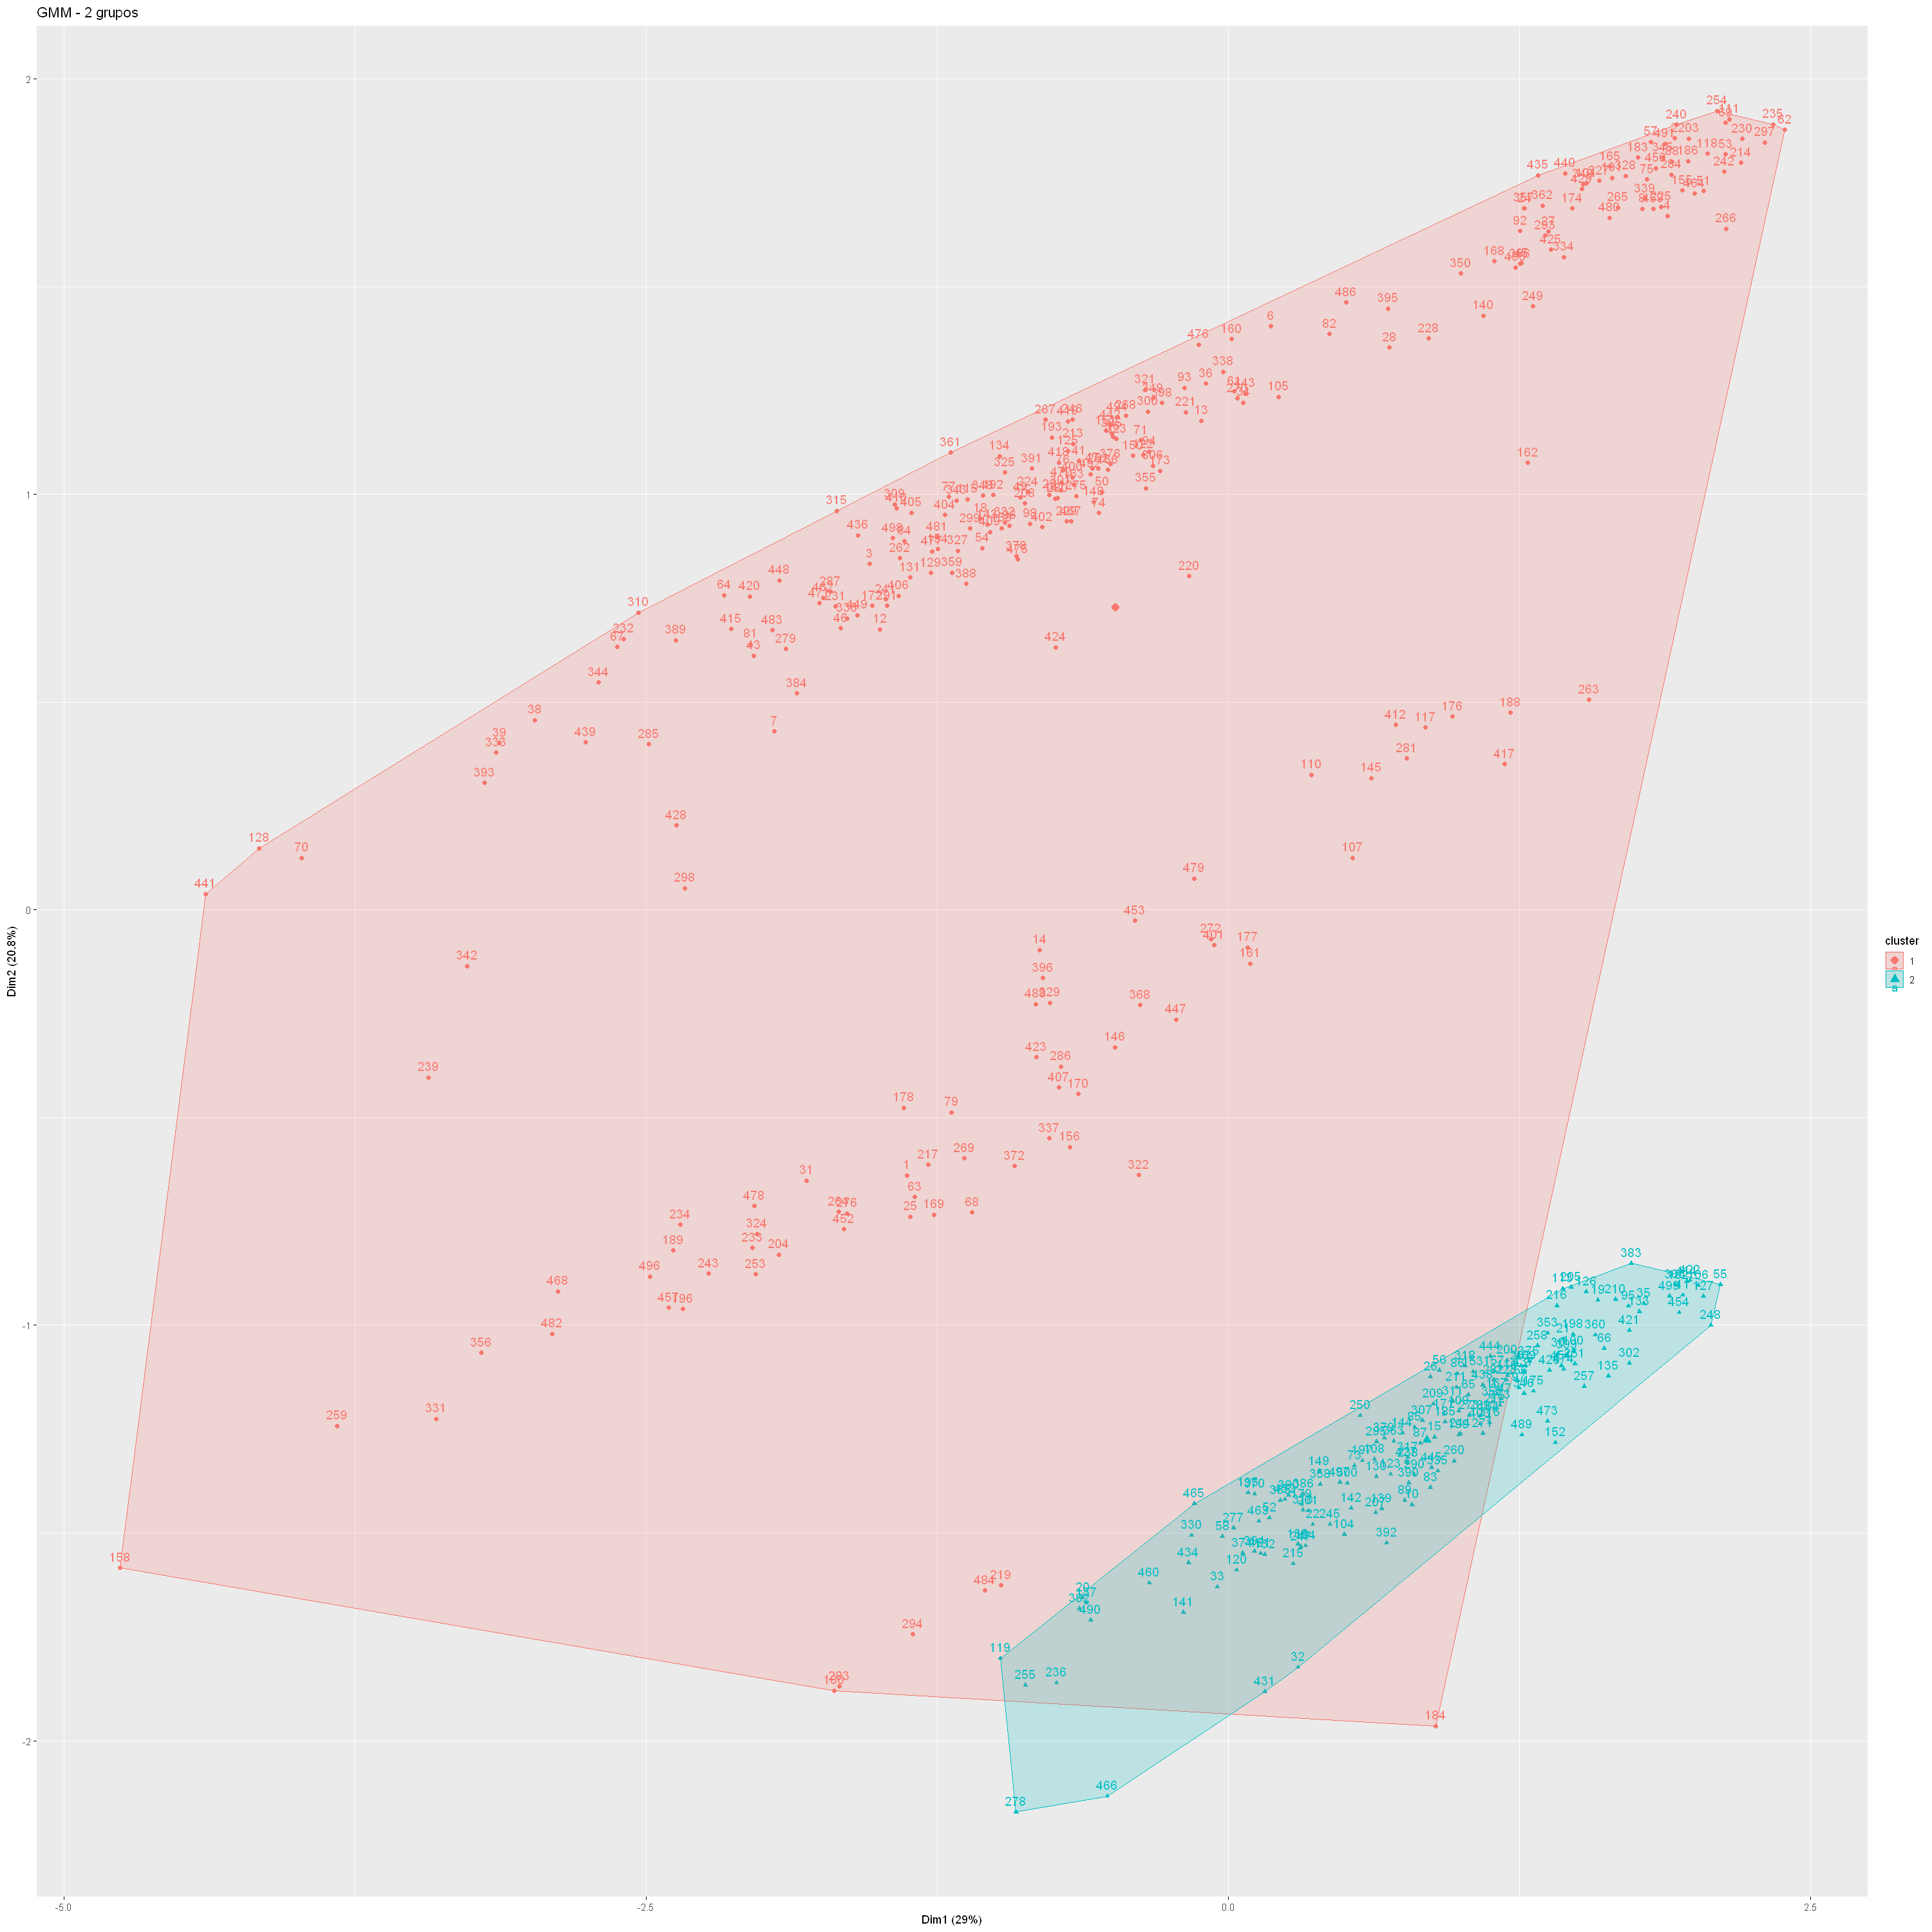

In [20]:
fviz_cluster(clus, datos_scale, main = paste("GMM -", clus$G, "grupos"))

### **Respuestas:**

**a) Realice el análisis de agrupamiento de los datos asignados a su grupo utilizando GMM.**

Graficos Anteriores

**b) Interprete sus resultados y compare con los obtenidos con k-means.**

Utilizando GMM se obtuvo un total de 2 grupos, a diferencia de K-Means donde se obtuvo un k óptimo de 4. Esta diferencia refleja en parte una decisión metodológica incorrecta en el preprocesamiento de los datos.
Tanto GMM como K-Means están diseñados para variables numéricas continuas. Al incorporar la variable categórica `modo_transporte` como columna binaria, se introdujo una estructura artificial en los datos que distorsiona los resultados. Si bien en K-Means los gráficos parecían satisfactorios, GMM dejó en evidencia esta falencia a través de las líneas diagonales observadas en la visualización, las cuales son un artefacto directo de las variables dummy y no representan grupos reales.
Desde un principio el objetivo fue buscar patrones que fueran más allá de simplemente agrupar por tipo de transporte, razón por la cual se mantuvo y transformó dicha columna. Sin embargo, la información del modo de transporte no permite observar directamente patrones de movilidad: indica el medio utilizado, pero no cómo se mueve la gente. Para capturar patrones de movilidad habría sido más pertinente incorporar la variable `viajes`, que representa la cantidad de viajes realizados, ya que junto a `distancia`, `tiempo` y `velocidad` podría haber revelado comportamientos de desplazamiento más significativos.
En conclusión, los resultados obtenidos con ambos métodos difieren considerablemente. K-Means generó una ilusión de buen agrupamiento, mientras que GMM expuso por qué no es adecuado utilizar variables categóricas codificadas como binarias en estos modelos.